In [1]:
import numpy as np
import torch
import os
import sys
import matplotlib.pyplot as plt
torch.set_default_dtype(torch.float64)
torch.autograd.set_detect_anomaly(False)
# debug._set_state(False)

from botorch.optim import optimize_acqf_discrete
from botorch.models.gp_regression import SingleTaskGP
import gpytorch

from gpytorch.constraints import Interval, GreaterThan
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood

# script_dir = os.path.dirname(os.path.realpath(sys.argv[0]))
cwd = os.getcwd()
src_dir = "/".join(cwd.split("/")[:-1]) # src directory is two levels up
sys.path.append(src_dir)

from src.acquisition_functions.posterior_sampling import gen_posterior_sampling_batch
from src.acquisition_functions.bax_acquisition import BAXAcquisitionFunction
# from src.fit_model import fit_model
# from src.bax.alg.levelset import LevelSetEstimator
from src.algorithms.levelset import LevelSetEstimator
from src.performance_metrics import F1Score
from src.experiment_manager import experiment_manager
# from src.fit_model import fit_model
from src.utils import (
    generate_initial_data,
    generate_random_points,
    get_obj_vals,
    seed_torch,
    optimize_acqf_and_get_suggested_batch,
    reshape_mesh, 
    get_mesh,
    get_function_samples,
)


/opt/conda/envs/PSBAX/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def fit_model(inputs, outputs):
    if len(outputs.shape) == 1:
        outputs = outputs.view(torch.Size([outputs.shape[0], 1]))
    model = SingleTaskGP(
        train_X=inputs,
        train_Y=outputs,
        covar_module=None,
        outcome_transform=Standardize(m=outputs.shape[-1]),
    )
    # register noise contraints to the model to be less than 1e-5
    model.likelihood.noise_covar.register_constraint(
        "raw_noise", Interval(7e-3, 1e-2)
    )
    model.covar_module.base_kernel.register_constraint(
        "raw_lengthscale", Interval(1.5e-1, 2e-1)
    )
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)

    return model
            

In [3]:
# means = torch.tensor([0.2, 0.5, 0.8])
# stds = torch.tensor([0.05, 0.05, 0.05])
# weights = torch.tensor([0.3, 0.4, 0.3])

seed_torch(1234)

means = torch.tensor([0.3, 0.7])  # Means of the Gaussians
stds = torch.tensor([0.1, 0.15]) # Standard deviations of the Gaussians
weights = torch.tensor([0.5, 0.5]) # Weights of the Gaussians, making the left mode higher
def obj_func(x, means=means, stds=stds, weights=weights):
    if isinstance(x, np.ndarray):
        x = torch.tensor(x)
    gaussians = [w * torch.exp(-0.5 * ((x - m) / s) ** 2) / (s * torch.sqrt(torch.tensor(2 * torch.pi))) for m, s, w in zip(means, stds, weights)]
    return torch.sum(torch.stack(gaussians), dim=0)

# inputs = torch.linspace(0, 1, 8).reshape(-1, 1)
inputs = torch.tensor([
    [0.13],
    # [0.1],
    [0.25],
    [0.47],
    [0.5714],
    [0.7143],
    [0.85],
    # [1.0000]
])
obj_vals = obj_func(inputs)

threshold = 1.1
kwargs = {}
model = fit_model(
    inputs,
    obj_vals,
)


x_set = np.linspace(0.1, 0.97, 1000).reshape(-1, 1)
algo_params = {
    "name" : "SimpleLevelSet",
    "threshold" : threshold,
    "x_set" : x_set,
    # "x_init" : x_init,
    "no_copy" : True,
}
algo = LevelSetEstimator(algo_params)

algo_gt = algo.get_copy()
exe_path_gt, output_gt = algo_gt.run_algorithm_on_f(obj_func)

batch_size = 1

In [4]:
# ps


algo_copy = algo.get_copy()
# x_next_ps = gen_posterior_sampling_batch(model, algo_copy, batch_size)
mc_values = {}
obj_func_sample = get_function_samples(model)
fsamp_vals = obj_func_sample(torch.from_numpy(x_set).unsqueeze(1)).detach().numpy() # (100, )

algo_samp = algo.get_copy()
x_output_ps = algo_samp.execute(obj_func_sample)
# get the max posterior variance of the output
var_out_post = model.posterior(torch.from_numpy(x_output_ps).unsqueeze(1)).variance.detach().numpy()
var_out_post = var_out_post.squeeze()
argmax_post = np.argmax(var_out_post)
x_max_post = x_output_ps[argmax_post].reshape(1, 1)

H_idx = np.where(fsamp_vals > threshold)[0]
H = x_set[H_idx].reshape(-1, 1)
H_values = fsamp_vals[H_idx]

L_idx = np.where(fsamp_vals <= threshold)[0]
L = x_set[L_idx].reshape(-1, 1)
L_values = fsamp_vals[L_idx]


In [6]:
x_set_left_idx = np.where(x_set < 0.5)[0]
x_set_right_idx = np.where(x_set >= 0.5)[0]

# intersection of H_idx and x_set_left_idx
H_idx_left = np.array(list(set(H_idx) & set(x_set_left_idx)))
H_idx_right = np.array(list(set(H_idx) & set(x_set_right_idx)))

In [33]:
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
plt.rcParams.update(plt.rcParamsDefault)
# plt.rcParams.update({
#     "text.usetex": False,
#     # "font.family": "sans-serif",
#     # "font.sans-serif": "Helvetica",
# })
from matplotlib.legend_handler import HandlerTuple

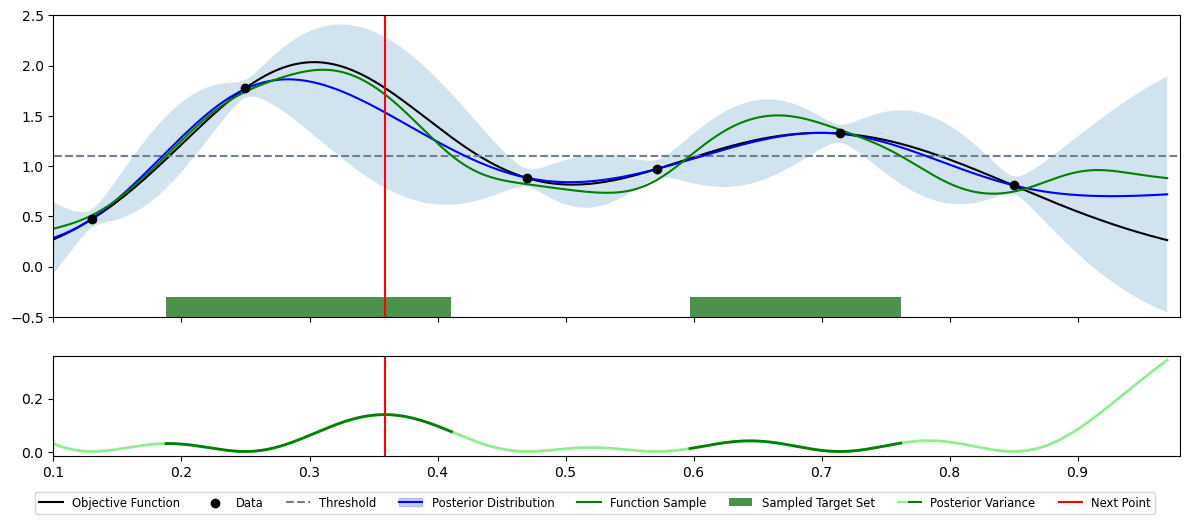

In [52]:
fig= plt.figure(figsize=(12, 5))

gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
ax = fig.add_subplot(gs[0])


y_true = obj_func(x_set)
ax.plot(
    x_set,
    y_true, 
    color="black",
    linewidth=1.5,
    label=r"Objective Function",
)

ax.scatter(
    inputs, 
    obj_vals, 
    color="black", 
    label="Data",
    zorder=10,
)

# ax.axhline(y=threshold, color="red", linestyle="--", label="Threshold")   
ax.plot(
    [0, 1], [threshold, threshold], color="slategrey", linestyle="--", label="Threshold"
)

posterior = model.posterior(torch.from_numpy(x_set).unsqueeze(1))
mean, var = posterior.mean.detach().squeeze().numpy(), posterior.variance.detach().squeeze().numpy()
std = np.sqrt(var)
ax.plot(
    x_set, 
    mean, 
    linewidth=1.5,
    # alpha=0.5,
    color="blue",
    label="nolegend",
)
ax.fill_between(x_set.flatten(), mean - 2*std, mean + 2*std, alpha=0.2)
custom_handles = [
    (Line2D([0.1], [0.1], color='blue'), Patch(color='blue', alpha=0.2)),
]

fsamp_vals = obj_func_sample(torch.from_numpy(x_set).unsqueeze(1)).detach().numpy()
ax.plot(
    x_set, 
    fsamp_vals, 
    color="green",
    label=r"Function Sample",
    # linestyle="--",
    linewidth=1.5,
)

# feasible region
x1 = min(x_output_ps).item()
lh = x_output_ps[np.where(x_output_ps < 0.5)]
x2 = max(lh).item()
x3 = min(x_output_ps[np.where(x_output_ps > 0.5)]).item()
x4 = max(x_output_ps).item()
patch1 = patches.Rectangle((x1, -0.5), x2 - x1, 0.2, alpha=0.7, edgecolor='none', facecolor='darkgreen', label=r"Sampled Target Set")
patch2 = patches.Rectangle((x3, -0.5), x4 - x3, 0.2, alpha=0.7, edgecolor='none', facecolor='darkgreen')
ax.add_patch(patch1)
ax.add_patch(patch2)
ax.set_xlim([0.1, 0.98])
ax.set_ylim([-0.5, 2.5])

ax2 = fig.add_subplot(gs[1], sharex=ax)
line1,  = ax2.plot(
    x_set,
    var,
    color="lightgreen",
    linewidth=2,
    label="Posterior Variance",
)
ax2.plot(
    x_set[H_idx_left],
    var[H_idx_left],
    color="green",
    linewidth=2,
)
ax2.plot(
    x_set[H_idx_right],
    var[H_idx_right],
    color="green",
    linewidth=2,
)

class TwoColorLineHandler(HandlerLine2D):
    def __init__(self, colors=['lightgreen', 'green']):
        super().__init__()
        self.colors = colors

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        legline, = super().create_artists(legend, orig_handle, xdescent, ydescent,
                                          width, height, fontsize, trans)
        
        # Create two line segments
        legline.set_color(self.colors[0])
        line1 = plt.Line2D([0, 0.5*width], [0.5*height, 0.5*height], color=self.colors[0])
        line2 = plt.Line2D([0.5*width, width], [0.5*height, 0.5*height], color=self.colors[1])
        
        return [line1, line2]

y_max_post = obj_func(x_max_post).squeeze().numpy()
# draw a vertical line at the selected point
ax.axvline(x=x_max_post, color="red", linestyle="-", label ="Next Point")
ax2.axvline(x=x_max_post, color="red", linestyle="-")


handles, labels = [], []
next_h, next_l = None, None
for ax_ in [ax, ax2]:
    for h, l in zip(*ax_.get_legend_handles_labels()):
        if l == "nolegend":
            handles.extend(custom_handles)
            labels.extend(["Posterior Distribution"])
        elif l == "Next Point":
            next_h = h
            next_l = l
            continue
        else:
            handles.append(h)
            labels.append(l)
handles.append(next_h)
labels.append(next_l)

plt.tight_layout()
plt.setp(ax.get_xticklabels(), visible=False)

# Create a single legend at the bottom
fig.legend(
    handles, 
    labels, 
    loc='lower center', 
    ncol=len(labels), 
    fontsize="small", 
    bbox_to_anchor=(0.5, -0.05), 
    handler_map={
        tuple: HandlerTuple(ndivide=1),
        line1: TwoColorLineHandler(),},
    )
plt.savefig(
    f"demo_levelset.pdf",
    bbox_inches="tight",
    dpi=300,
)
plt.show()


In [40]:
ax2.collections


<Axes.ArtistList of 0 collections>

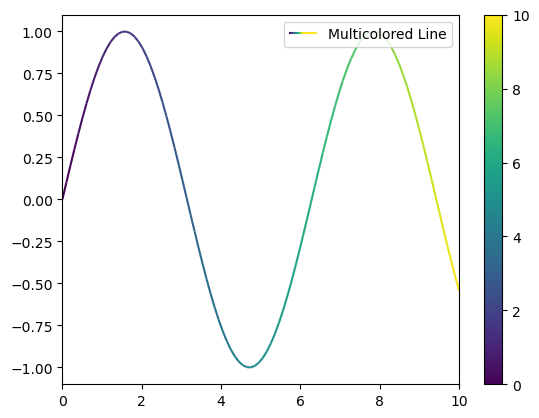

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.legend_handler import HandlerLineCollection

class CustomHandlerLineCollection(HandlerLineCollection):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        x = np.linspace(0, width, 100)
        y = 0.5 * height * np.ones_like(x)
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = LineCollection(segments, cmap=orig_handle.cmap, norm=orig_handle.norm)
        lc.set_array(x)
        lc.set_linewidth(orig_handle.get_linewidths()[0])
        return [lc]

# Generate data for the plot
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create a LineCollection
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)
lc = LineCollection(segments, cmap='viridis', norm=plt.Normalize(0, 10))
lc.set_array(x)

# Create the plot
fig, ax = plt.subplots()
line = ax.add_collection(lc)
ax.set_xlim(x.min(), x.max())
ax.set_ylim(-1.1, 1.1)

# Add a colorbar
plt.colorbar(line, ax=ax)

# Add a legend with the custom handler
ax.legend([lc], ['Multicolored Line'], 
          handler_map={LineCollection: CustomHandlerLineCollection()})

plt.show()

objective function, data, threshold, posterior distribution, function sample, sampled target set, posterior variance, next point

In [ ]:
# fig= plt.figure(figsize=(12, 5))

# gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
# ax = fig.add_subplot(gs[0])


# y_true = obj_func(x_set)
# ax.plot(
#     x_set,
#     y_true, 
#     color="black",
#     linewidth=1.5,
#     label=r"Objective Function $f$",
# )

# posterior = model.posterior(torch.from_numpy(x_set).unsqueeze(1))
# mean, var = posterior.mean.detach().squeeze().numpy(), posterior.variance.detach().squeeze().numpy()
# std = np.sqrt(var)
# ax.plot(
#     x_set, 
#     mean, 
#     linewidth=1.5,
#     # alpha=0.5,
#     color="blue",
#     label="nolegend",
# )
# ax.fill_between(x_set.flatten(), mean - 2*std, mean + 2*std, alpha=0.2)

# custom_handles = [
#     (Line2D([0.1], [0.1], color='blue'), Patch(color='blue', alpha=0.2)),
# ]


# fsamp_vals = obj_func_sample(torch.from_numpy(x_set).unsqueeze(1)).detach().numpy()
# ax.plot(
#     x_set, 
#     fsamp_vals, 
#     color="green",
#     label=r"Function Sample $\tilde{f}$",
#     # linestyle="--",
#     linewidth=1.5,
# )

# # ax.axhline(y=threshold, color="red", linestyle="--", label="Threshold")   
# ax.plot(
#     [0, 1], [threshold, threshold], color="slategrey", linestyle="--", label="Threshold"
# )

# # feasible region
# x1 = min(x_output_ps).item()

# lh = x_output_ps[np.where(x_output_ps < 0.5)]
# x2 = max(lh).item()
# x3 = min(x_output_ps[np.where(x_output_ps > 0.5)]).item()
# x4 = max(x_output_ps).item()

# # plot the feasible region on the x-axis as a grey area
# # ax.plot([x1, x2], [0, 0.5], color="grey", alpha=0.5)
# # ax.plot([x3, x4], [0, 0.5], color="grey", alpha=0.5)
# patch1 = patches.Rectangle((x1, -0.5), x2 - x1, 0.2, alpha=0.7, edgecolor='none', facecolor='darkgreen', label=r"Sampled Target Set $X_n= \mathcal{O}_{ \mathcal{A}}(\tilde f)$")
# patch2 = patches.Rectangle((x3, -0.5), x4 - x3, 0.2, alpha=0.7, edgecolor='none', facecolor='darkgreen')
# ax.add_patch(patch1)
# ax.add_patch(patch2)
# ax.set_xlim([0.1, 0.98])
# ax.set_ylim([-0.5, 2.5])

# ax2 = fig.add_subplot(gs[1], sharex=ax)
# # ax2.scatter(
# #     H,
# #     var[H_idx],
# #     color="green",
# #     marker="o",
# #     s=10,
# #     label="Posterior Variance"
# # )
# # ax2.scatter(
# #     L,
# #     var[L_idx],
# #     color="lightgreen",
# #     marker="o",
# #     s=10,
# #     alpha=0.1,
# #     # label="Posterior Variance"
# # )
# # H_idx_left = np.where(x_set[H_idx] < 0.5)[0]
# # H_idx_right = np.where(x_set[H_idx] >= 0.5)[0]
# ax2.plot(
#     x_set,
#     var,
#     color="lightgreen",
#     linewidth=2,
#     label="Posterior Variance",
# )
# ax2.plot(
#     x_set[H_idx_left],
#     var[H_idx_left],
#     color="green",
#     linewidth=2,
# )
# ax2.plot(
#     x_set[H_idx_right],
#     var[H_idx_right],
#     color="green",
#     linewidth=2,
# )


# plt.setp(ax.get_xticklabels(), visible=False)


# # y_output = obj_func_sample(torch.from_numpy(x_output_ps).unsqueeze(1)).squeeze().numpy()
# # ax.scatter(x_output_ps, y_output, color="red", label="Level Set Estimate")

# # ax.plot(x_set, acq_vals, label="BAX Acquisition Function")

# y_max_post = obj_func(x_max_post).squeeze().numpy()
# # ax.scatter(
# #     x_next_ps.squeeze().numpy(), 
# #     y_next_ps, 
# #     color="blue", 
# #     marker="x",
# #     s=100,
# #     label="Selected Point"
# # )
# # draw a vertical line at the selected point
# ax.axvline(x=x_max_post, color="red", linestyle="-", label ="Next Point")
# ax2.axvline(x=x_max_post, color="red", linestyle="-")

# ax.scatter(
#     inputs, 
#     obj_vals, 
#     color="black", 
#     label="Data",
#     zorder=10,
# )

# # y_next_bax = obj_func_sample(x_next_bax.unsqueeze(1)).squeeze().numpy()
# # ax.scatter(x_next_bax.squeeze().numpy(), y_next_bax, color="purple", label="BAX next")

# handles, labels = [], []
# next_h, next_l = None, None
# for ax_ in [ax, ax2]:
#     for h, l in zip(*ax_.get_legend_handles_labels()):
#         if l == "nolegend":
#             handles.extend(custom_handles)
#             labels.extend(["Posterior Distribution"])
#         elif l == "Next Point":
#             next_h = h
#             next_l = l
#             continue
#         else:
#             handles.append(h)
#             labels.append(l)
# handles.append(next_h)
# labels.append(next_l)
# plt.tight_layout()

# # Create a single legend at the bottom
# fig.legend(handles, labels, loc='lower center', ncol=5, fontsize="small", bbox_to_anchor=(0.5, -0.1))
# plt.savefig(
#     f"demo_levelset.pdf",
#     bbox_inches="tight",
#     dpi=300,
# )
# plt.show()
